In [1]:
import numpy as np
import pickle
import pandas as pd
import math
from time import time
from geneticalgorithm import geneticalgorithm as ga

In [2]:
# Solar PV parameters
Pmax_PV = 3000                                                                   # 3 GW / 3000 MW
Rc = 120                                                                         # Irradiance point (W/m^2)
Gstd = 1000                                                                      # standard_irradiance (W/m^2)
PV_costs = 0.7                                                                   # O&M cost for PV arrays

# Battery parameters
Ebess_min = 0.3         # MWh
Ebess_max = 1.5         # MWh
Estart = 0.3            # MWh
B_eff_chg = 0.9
B_eff_dischg = 0.9
IC_bess = 80 * Ebess_max                               # Investment cost of BESS
LCN = 2000                                             # Life cycle number of BESS
Ebess_coef = IC_bess/(Ebess_max * LCN)                 # Battery co-efficient (gamma)

# Generator parameters
a = [0.07, 0.08, 0.09]           # Quadratic cost coefficient
b = [87, 100, 150]              # Linear cost coefficient
c = [18, 21, 24]                    # Constant cost
P_min = [0, 0, 0]                   # Min power output
P_max = [2, 3, 4]                   # Max power output
ramp_up = [1, 1.2, 1.5]             # Ramp-up limit
ramp_down = [1, 1.2, 1.5]           # Ramp-down limit
init_prod = [1, 1.5, 1.5]               # Initial production levels for the generators

# Startup/shutdown costs and thresholds
hot_start_cost = [12, 13, 14]  # Hot startup cost for each generator
cold_start_cost = [25, 26, 27] # Cold startup cost

# Minimum up/down times (hours)
min_up_time = [3, 3, 3]  # Minimum time generator must stay on
min_down_time = [3, 3, 3]  # Minimum time generator must stay off

# Grid
PG_max = 2

In [3]:
# Load data
with open('scenario_demand_data_2020.pickle', 'rb') as file_a:
  load_demand = pickle.load(file_a)

with open('scenario_price_data_2020.pickle', 'rb') as file_b:
  price = pickle.load(file_b)

with open('scenario_solar_data_2020.pickle', 'rb') as file_c:
  solar_irradiance = pickle.load(file_c)
  # Filling the solar_irradiance dataframe
  index = pd.date_range(start='2020-01-15 06:00:00', end='2020-01-15 19:00:00', freq='h')
  df = pd.DataFrame(solar_irradiance, index=index)
  # Create a complete time range for the day
  full_index = pd.date_range(start='2020-01-15 00:00:00', end='2020-01-15 23:00:00', freq='h')
  # Merge the original DataFrame with the complete time range, filling missing values with zeros
  solar_irradiance = df.reindex(full_index, fill_value=0)

# Extract data
load_demand = load_demand['prediction'].values
price = price['prediction'].values
solar_irradiance = solar_irradiance['prediction'].values

# Converting solar irradiance to solar power
len_solar = len(solar_irradiance)
solar_power = [None] * len_solar

for t in range(len_solar):
  if 0 < solar_irradiance[t] < Rc:
    solar_power[t] = Pmax_PV * (solar_irradiance[t] ** 2 / (Gstd * Rc))
  else:
    solar_power[t] = Pmax_PV * (solar_irradiance[t]/Gstd)

solar_power = np.array(solar_power)

# Normalize the test data
solar_power = solar_power/1000
load = (load_demand * 0.5)/1000
grid_cost = price

In [4]:
# Define the EMS objective function
def f(X):
    total_cost = 0
    power_bal_penalty = 0
    bess_penalty = 0
    gen_pen = 0
    ramp_penalty = 0
    min_up_down_penalty = 0
    Ebess = Estart

    # Track generator statuses
    gen_on_time = [0, 0, 0]  # For minimum up time tracking
    gen_off_time = [0, 0, 0]  # For minimum down time and startup tracking
    previous_status = [1, 0, 0]  # Track generator status for min up/down times

    # Loop through each time (24 hours)
    for t in range(24):
        # Extract generator statuses and power
        X1, X2, X3 = X[t * 7 + 0], X[t * 7 + 1], X[t * 7 + 2]
        P1, P2, P3 = X[t * 7 + 3], X[t * 7 + 4], X[t * 7 + 5]
        P_energy = X[t * 7 + 6]  # Battery power

        # If the generator is off, set power to zero
        P = [P1, P2, P3]
        X_gen_status = [X1, X2, X3]

        for i in range(3):
            P[i] = 0 if X_gen_status[i] == 0 else np.clip(P[i], P_min[i], P_max[i])

        # Update generator status (for min up/down time and startup cost)
        startup_costs = 0
        for i in range(3):
            if X_gen_status[i] == 1:  # Generator is ON
                if gen_off_time[i] > 0:  # It was OFF, now it's ON (startup)
                    # Check for hot or cold startup
                    if gen_off_time[i] > min_down_time[i]:
                        startup_costs += cold_start_cost[i]  # Cold startup
                    else:
                        startup_costs += hot_start_cost[i]  # Hot startup
                    gen_off_time[i] = 0  # Reset off time tracker
                gen_on_time[i] += 1  # Increase ON time
                if gen_on_time[i] < min_up_time[i]:
                    min_up_down_penalty += 500
            else:  # Generator is OFF
                if gen_on_time[i] > 0:  # It was ON, now it's OFF (shutdown)
                    gen_on_time[i] = 0  # Reset ON time tracker
                gen_off_time[i] += 1  # Increase OFF time
                if gen_off_time[i] < min_down_time[i]:
                    min_up_down_penalty += 500

        previous_status = X_gen_status

        # Set bounds for P_charge and P_discharge based on P_energy
        if P_energy < 0:  # Charging mode
            P_charge = -P_energy
            P_discharge = 0
        elif P_energy > 0:  # Discharging mode
            P_discharge = P_energy
            P_charge = 0
        else:
            P_charge = 0
            P_discharge = 0

        # Calculate battery energy
        Ebess = Ebess + (P_charge * B_eff_chg) - (P_discharge / B_eff_dischg)

        # Ensure battery limits are respected
        if Ebess < Ebess_min or Ebess > Ebess_max:
            bess_penalty += 500

        # Apply ramp constraint and penalties
        for i in range(3):
            if t == 0:  # First time period, use initial production levels
                prev_P = init_prod[i]
            else:
                prev_P = X[(t - 1) * 7 + 3 + i]
            if P[i] - prev_P > ramp_up[i]:
                ramp_penalty += 500
            elif prev_P - P[i] > ramp_down[i]:
                ramp_penalty += 500

        # Calculate total generated power
        total_generation = P[0] + P[1] + P[2] + P_energy + solar_power[t]

        # Constraints: Power balance
        if (total_generation < load[t]):
            power_bal_penalty += 1000
            P_net = load[t] - total_generation
            P_grid = min(P_net, PG_max)
        else:
            P_grid = 0
            power_bal_penalty += 0

        # Calculate costs for each generator based on the ON/OFF status
        cost_1 = X1 * (a[0] * P[0]**2 + b[0] * P[0] + c[0])
        cost_2 = X2 * (a[1] * P[1]**2 + b[1] * P[1] + c[1])
        cost_3 = X3 * (a[2] * P[2]**2 + b[2] * P[2] + c[2])
        cost_grid = grid_cost[t] * P_grid
        cost_solar = solar_power[t] * PV_costs
        Ebess_degrad_costs = (Ebess_coef * abs(P_energy)) + (Ebess_coef * Ebess)

        # Total cost for this time period
        total_cost += cost_1 + cost_2 + cost_3 + cost_grid + cost_solar + Ebess_degrad_costs + startup_costs

    # Return total cost including penalties
    return total_cost + power_bal_penalty + bess_penalty + gen_pen + ramp_penalty + min_up_down_penalty

 The best solution found:                                                                           
 [ 1.          1.          1.          1.01707595  1.05700477  2.42887614
 -0.48125754  1.          1.          1.          1.10314225  2.48021853
  3.48484478 -0.05209008  1.          1.          1.          1.77070779
  0.37519111  1.56456147 -0.09883422  1.          1.          1.
  0.84333111  1.23309422  1.35514521  0.46598211  1.          1.
  1.          1.09284908  1.44866255  1.90587889 -0.28901462  1.
  1.          1.          0.80279269  1.30295131  2.83314373 -0.1890816
  1.          1.          1.          0.39335311  0.92740669  2.91966868
 -0.30815173  1.          1.          1.          0.86137683  1.85734042
  1.96176626 -0.3576111   1.          1.          1.          1.39390353
  1.33107357  1.47936147  0.04943726  1.          1.          1.
  0.72632783  2.09834475  0.55244161  0.16919485  1.          1.
  1.          0.98870892  1.36174587  0.71312135  0.29546901  1

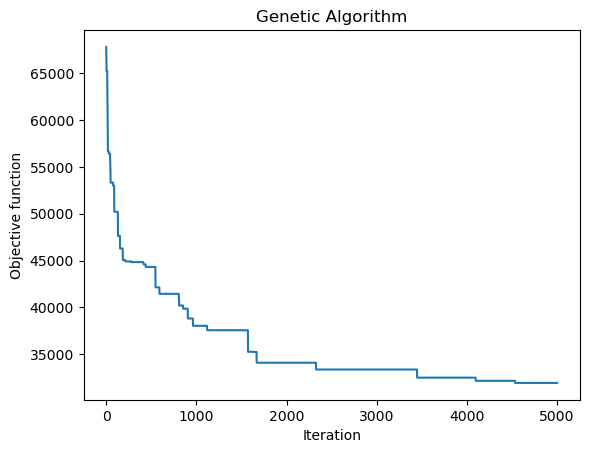

 The best solution found:                                                                           
 [ 0.          1.          1.          0.70440754  1.80521271  2.62508043
 -0.34282512  0.          1.          1.          0.24137725  1.19603191
  2.65950948 -0.06951576  0.          0.          1.          0.24451567
  0.50681451  3.52931754 -0.14593545  0.          0.          1.
  0.0356337   1.74483326  2.62848428 -0.16951338  0.          0.
  1.          1.63653112  0.88833522  2.95394579  0.25043515  1.
  0.          0.          0.90031551  0.55003635  3.69516404  0.03335623
  1.          0.          0.          0.59719333  2.36948549  1.25415258
  0.10663549  1.          1.          0.          1.44284443  2.90212904
  0.53780324 -0.37856819  1.          1.          0.          1.38728854
  2.80841142  1.05337525 -0.36254385  1.          0.          0.
  1.29369447  0.12003884  0.16986331  0.44951964  1.          0.
  0.          0.6029349   1.24849881  0.82962879 -0.08198368  

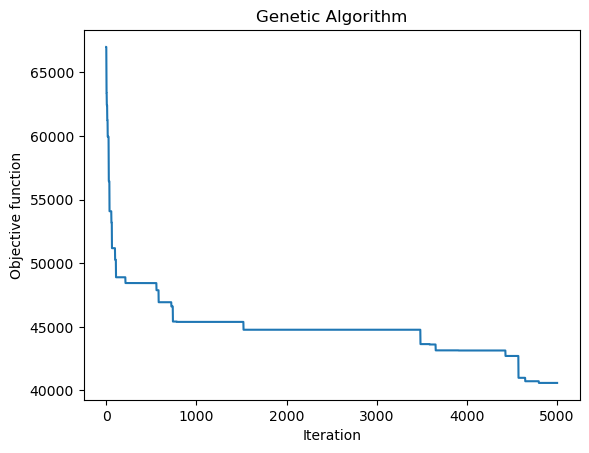

 The best solution found:                                                                           
 [ 1.          1.          1.          0.34516685  1.98532455  1.82543766
  0.04189943  1.          1.          1.          0.645569    1.17273188
  2.16560064 -0.20549855  1.          1.          1.          0.1649817
  1.48544279  1.30819192  0.08338767  1.          1.          1.
  1.0181898   2.07027615  2.84224543 -0.08251875  1.          1.
  1.          0.57641687  0.96761335  2.88785421 -0.43430272  1.
  1.          1.          1.29917709  1.43346677  1.78971478  0.18100665
  1.          1.          1.          1.48534389  2.27934151  0.9442599
  0.15425414  1.          1.          1.          0.8409779   2.84673698
  1.37895253  0.06465136  1.          1.          1.          1.34979306
  2.45341243  0.65709866  0.21819423  1.          1.          1.
  1.7931832   2.08458996  1.44510025 -0.35699473  1.          1.
  1.          1.64115441  0.9979341   2.04517812 -0.20122077  1.

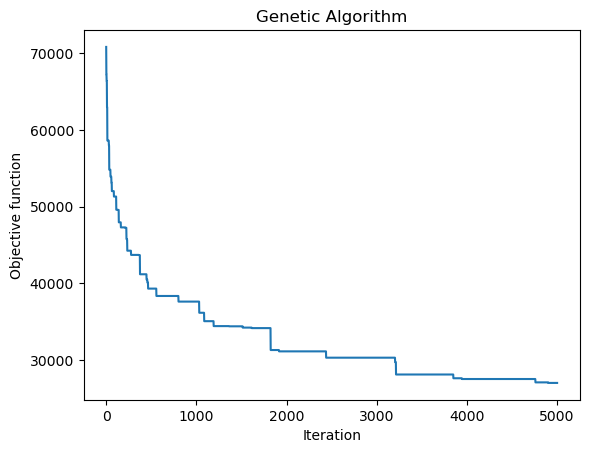

 The best solution found:                                                                           
 [ 0.          1.          0.          0.15311887  0.71427396  1.19081862
 -0.08906139  0.          0.          0.          0.93271186  1.05274983
  0.88916459 -0.33698844  0.          0.          0.          0.98568567
  0.40969353  0.69257183  0.195422    0.          0.          0.
  0.56956277  2.22243719  2.92193853 -0.37786969  0.          0.
  1.          0.49452462  0.22154564  1.52135783  0.12470074  1.
  0.          1.          0.45843864  0.45859176  0.11718993 -0.14941336
  1.          1.          1.          0.40840444  0.51015873  3.05895288
  0.0320919   1.          1.          1.          0.55373357  0.74911519
  3.26212615  0.17860051  1.          1.          1.          0.89924331
  1.52997     1.83688613 -0.17573535  1.          1.          1.
  0.32257319  1.0060621   3.62466949 -0.49309393  1.          1.
  1.          0.95286115  1.12595606  0.88016074  0.46239009  

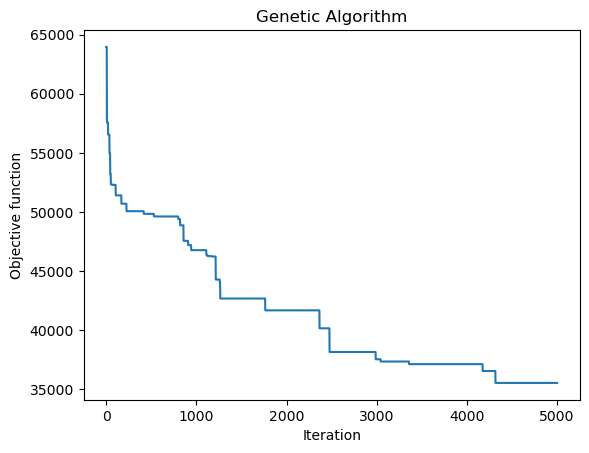

 The best solution found:                                                                           
 [ 1.00000000e+00  1.00000000e+00  1.00000000e+00  1.60219414e+00
  1.63267947e+00  1.84742408e+00 -1.48644245e-01  1.00000000e+00
  1.00000000e+00  1.00000000e+00  2.90376483e-01  1.55760261e+00
  2.21669610e+00 -4.26571273e-01  1.00000000e+00  1.00000000e+00
  1.00000000e+00  4.33585418e-01  2.35840392e+00  2.46654967e+00
  2.12364133e-01  1.00000000e+00  1.00000000e+00  1.00000000e+00
  6.12240367e-01  1.72215938e+00  1.87239655e+00  1.53383736e-01
  1.00000000e+00  1.00000000e+00  1.00000000e+00  9.62693051e-01
  1.41840558e+00  1.69426472e+00 -4.86555294e-01  1.00000000e+00
  1.00000000e+00  1.00000000e+00  5.21584638e-01  1.52821572e+00
  1.95422844e+00  1.43528173e-01  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.39662994e+00  2.16034986e+00  1.42222594e+00
 -6.96500271e-02  1.00000000e+00  1.00000000e+00  1.00000000e+00
  9.99139342e-01  1.28240634e+00  3.53229337e-01 -2.9

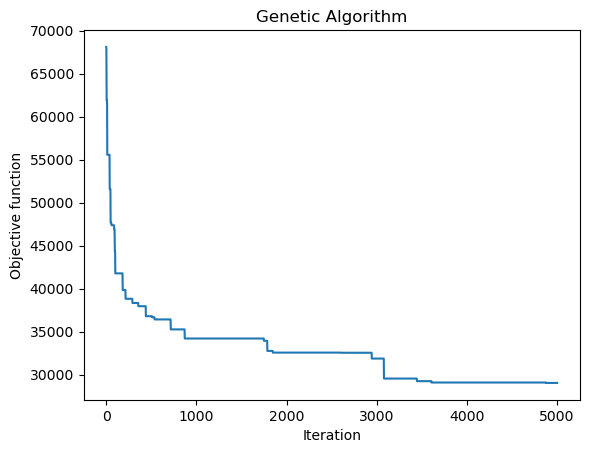

 The best solution found:                                                                           
 [ 0.          1.          1.          1.56644197  1.5037035   2.22311991
  0.36727751  0.          1.          1.          0.82652702  1.70984951
  2.28999165 -0.43733653  1.          1.          1.          0.90567057
  2.79309268  2.20074705 -0.14559551  1.          1.          1.
  0.59069358  1.81301703  3.02931118 -0.15632601  1.          1.
  1.          1.03045923  1.17296866  1.66437661 -0.19961626  1.
  1.          1.          1.07294842  0.81177235  2.87565738 -0.28799778
  1.          1.          1.          0.90295628  1.76148616  3.93814335
  0.24838561  1.          1.          1.          1.43421176  2.4503009
  2.11566626  0.21897998  1.          1.          1.          0.54908443
  1.47204262  3.39485086 -0.46955047  1.          1.          1.
  0.76858209  0.77492834  2.53116297 -0.38358485  1.          1.
  1.          1.56742343  1.07276771  0.09363792  0.01625871  1

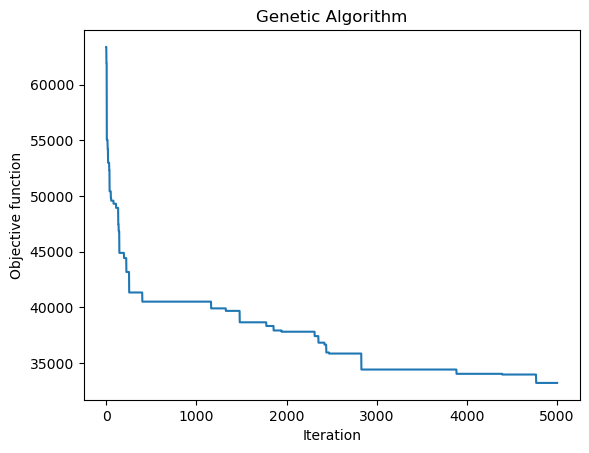

 The best solution found:                                                                           
 [ 1.          1.          1.          1.57440867  1.83720617  1.05870866
 -0.38742909  1.          1.          0.          1.44383563  1.17844332
  0.61355082  0.06061453  1.          1.          0.          0.53894061
  1.21475027  0.12321323 -0.42162086  0.          1.          0.
  0.51020533  1.41041076  0.81584226  0.2278919   0.          1.
  0.          0.98862497  0.51097843  3.30189608 -0.27378344  0.
  1.          1.          0.67180291  1.48206226  3.87917545 -0.03570397
  0.          1.          1.          1.54657467  2.15766488  1.80983176
  0.02937134  0.          1.          1.          0.8347207   2.24815108
  3.19726472 -0.1358189   0.          1.          1.          1.760484
  1.86586749  2.37161095  0.26550989  0.          1.          1.
  0.88382408  2.18481524  1.29627995 -0.2945215   0.          1.
  1.          0.99845971  1.84550397  1.84251624  0.33147782  0.

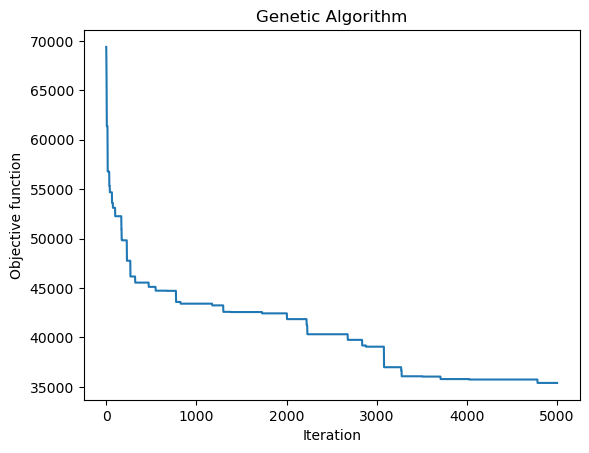

 The best solution found:                                                                           
 [ 0.          1.          0.          0.12502747  1.12683286  0.54487668
 -0.33176071  1.          1.          0.          0.89162719  1.98118789
  0.24374501 -0.10393019  1.          1.          0.          1.89164039
  1.75137181  2.46012519  0.08028131  1.          1.          1.
  1.44347819  1.22265836  2.53155561 -0.43296612  1.          1.
  1.          1.49648794  1.47479192  1.42705404  0.04118316  1.
  1.          1.          1.58158522  1.21769547  1.97156384 -0.13179515
  1.          1.          1.          0.81153346  2.04493208  1.59700659
 -0.07022208  1.          1.          1.          1.78696813  1.9118242
  0.53731388 -0.30427925  1.          1.          0.          1.36472705
  2.28760339  3.00238175  0.17087678  1.          1.          0.
  1.23177786  2.5724019   1.33774477  0.39541975  1.          1.
  0.          1.68221379  2.04153417  1.1601466  -0.40672534  1

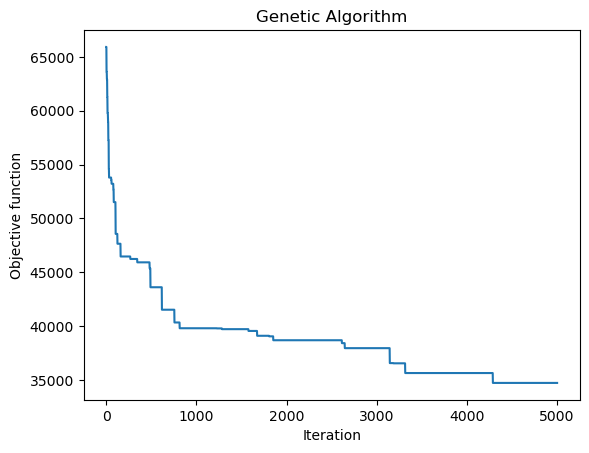

 The best solution found:                                                                           
 [ 0.          1.          1.          0.51953578  0.58327917  3.63350514
 -0.4282079   0.          1.          0.          0.74425488  0.46208575
  0.92631473 -0.47679666  0.          1.          0.          0.39735126
  0.11730274  1.26396353 -0.1884946   0.          0.          0.
  0.41716912  0.46651125  3.5247877   0.44698484  0.          0.
  0.          0.35957637  0.48524637  0.75423628 -0.32994206  0.
  0.          0.          1.13541083  0.249836    1.66819471 -0.08464937
  1.          0.          0.          0.25623436  0.67598101  0.83656836
  0.04102589  1.          0.          0.          1.130227    0.86201879
  0.0717541   0.10453234  1.          0.          0.          1.59051026
  1.06160873  1.32142905  0.0405721   1.          0.          0.
  0.15189281  2.41376029  2.90291609 -0.36133966  1.          0.
  1.          0.83021179  0.86554555  0.13278658  0.36567683  

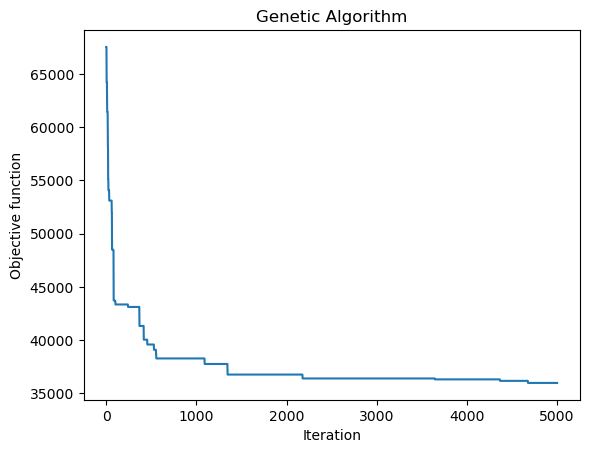

 The best solution found:                                                                           
 [ 1.00000000e+00  1.00000000e+00  1.00000000e+00  1.34328799e+00
  1.40396006e+00  1.06873702e+00  8.42919405e-02  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.99605682e+00  4.32351747e-01
  2.28630390e+00 -4.46829880e-01  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.72790876e+00  1.31215160e+00  3.19572975e+00
 -3.15839934e-01  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.39746059e+00  2.17573472e+00  1.36286333e-03  4.03859983e-01
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.59499477e+00
  1.94836229e+00  2.37098337e+00 -9.33612366e-02  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.12209172e+00  8.81619304e-01
  2.39114078e+00 -2.15666295e-02  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.27238199e+00  2.98366005e+00  9.19624088e-01
 -1.85049510e-01  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.60026244e+00  2.25255355e+00  8.14659348e-01 -3.4

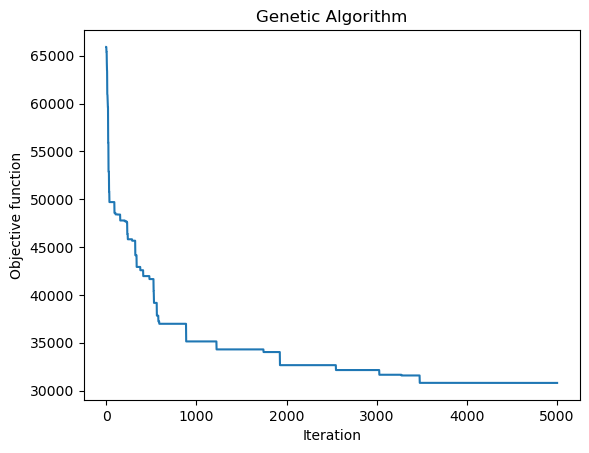

 The best solution found:                                                                           
 [ 1.          1.          1.          1.22000584  1.4963408   1.93676412
 -0.29710914  1.          0.          1.          0.27426149  0.70196533
  3.86538308 -0.16895005  1.          0.          1.          0.56237786
  0.30172064  3.55824936 -0.37093709  1.          0.          1.
  0.86064607  1.09693105  3.64434893  0.38631627  1.          1.
  1.          1.28414179  1.82645005  2.62531388  0.23266113  1.
  1.          1.          0.42781419  2.17447061  1.81834948 -0.16530892
  1.          1.          1.          1.3623121   2.89984315  2.93761398
 -0.34541545  1.          1.          1.          0.95782281  2.13552718
  2.84193048 -0.2699889   1.          1.          1.          1.72171068
  0.86737135  3.13275592  0.48040511  1.          1.          1.
  1.38688757  2.01144525  1.80220546 -0.36731998  1.          1.
  1.          0.24023973  1.70745836  1.64086062 -0.34974709  

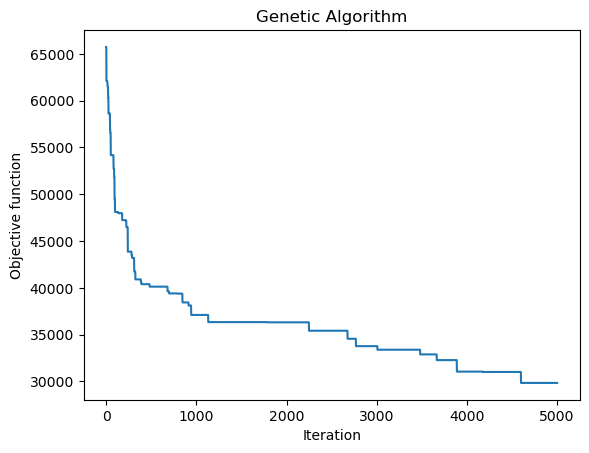

 The best solution found:                                                                           
 [ 0.          1.          1.          1.3907039   2.10051112  2.22333788
 -0.28843611  1.          1.          1.          1.16029392  1.10552703
  3.70839092 -0.47534767  1.          1.          1.          0.11980298
  0.83491979  3.14739268  0.30935458  1.          1.          1.
  0.36758735  2.02603297  1.49284626 -0.41842416  1.          1.
  1.          0.66607102  0.99171412  1.72954324 -0.04679598  0.
  1.          1.          1.33571783  1.42601772  2.70006695 -0.02908887
  1.          1.          1.          0.92799658  2.49721905  3.81785446
 -0.09521985  0.          1.          1.          0.89610843  2.22821943
  2.34863322  0.38501141  0.          1.          1.          1.07234934
  2.93328323  0.66600692 -0.25120164  0.          1.          1.
  1.12368764  1.35613749  0.25982286 -0.31968541  1.          1.
  1.          1.71885562  1.2910103   1.5204387   0.23649085  

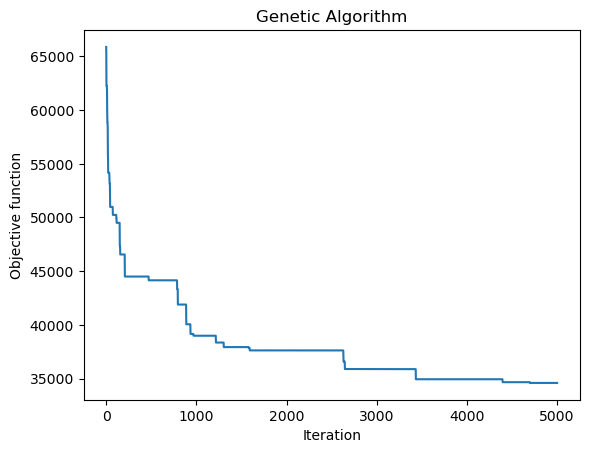

 The best solution found:                                                                           
 [ 0.          1.          1.          1.13126139  2.32344482  1.95599757
 -0.21951265  1.          1.          1.          1.13896339  2.55100971
  0.63123996 -0.28190689  1.          1.          1.          1.68932971
  2.60164231  0.1309424  -0.09705187  1.          1.          1.
  1.66409728  1.55118761  0.31282902 -0.01971918  1.          1.
  1.          1.53199138  1.1159771   2.20449623 -0.0135943   1.
  1.          1.          1.02102277  2.0798187   1.73740277  0.26037985
  1.          1.          1.          1.87068248  2.84885701  3.32387329
  0.03636278  1.          1.          1.          1.61671618  0.01418083
  3.15846678 -0.42101241  0.          1.          1.          0.97954605
  0.57516729  3.55757398  0.29490054  0.          1.          1.
  0.71459286  0.82575355  2.38698495 -0.20669526  0.          1.
  1.          0.72382477  1.1209827   2.3694126  -0.30263055  

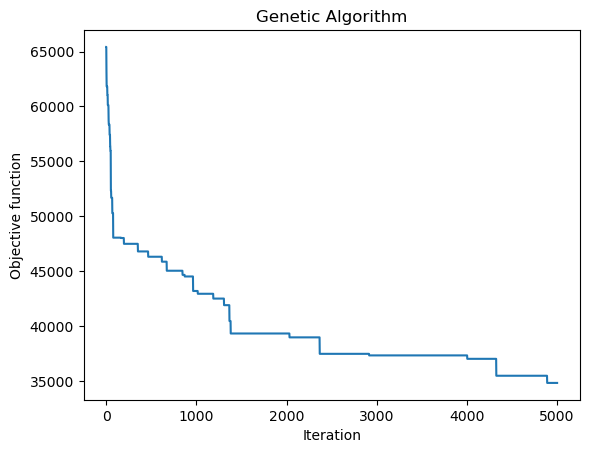

 The best solution found:                                                                           
 [ 1.          1.          1.          1.13464038  2.02952707  1.55875982
 -0.31788249  1.          1.          1.          0.66876071  2.57990883
  0.8861235  -0.35194415  1.          1.          1.          0.66044811
  1.56048104  2.18888795  0.09127273  1.          1.          1.
  1.09471607  1.92075668  3.05978047 -0.35779665  1.          1.
  1.          1.29234268  0.90237645  0.25745469 -0.251703    1.
  1.          1.          0.83743625  1.16611792  0.3525347   0.4199098
  1.          1.          1.          1.46420226  2.32098153  1.41889157
 -0.3625086   1.          1.          1.          1.54887079  1.57933671
  0.24723335  0.25770608  1.          1.          1.          1.84360075
  2.64536571  0.42967594 -0.13714632  1.          1.          1.
  1.89191092  1.84902808  2.78931766  0.14113074  1.          1.
  1.          1.09257701  0.98123904  1.05143702  0.35805771  1

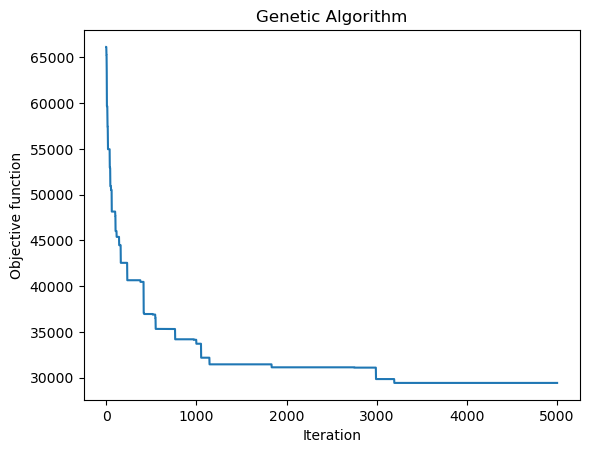

 The best solution found:                                                                           
 [ 1.          1.          1.          1.59074213  1.48298311  1.18927705
 -0.28382556  0.          1.          1.          0.25935804  2.61999616
  1.41666082 -0.45210404  0.          1.          1.          0.32060156
  1.56425637  2.00973839  0.33757376  0.          1.          1.
  1.67103836  1.66473637  3.37505686 -0.20229703  0.          1.
  1.          1.65752583  2.3696081   3.80589676 -0.49007431  1.
  1.          1.          0.95458423  0.44071392  2.67971047  0.39121886
  1.          1.          1.          0.44452523  0.71309752  2.53887351
  0.20019425  0.          1.          1.          1.11798228  1.49232782
  3.68339521 -0.47811793  1.          1.          1.          1.39744685
  1.26717148  3.27312237 -0.37643188  1.          1.          1.
  0.74651616  1.55287757  2.38898429 -0.15303781  1.          1.
  1.          1.45904941  2.3525771   1.49974225  0.05733771  

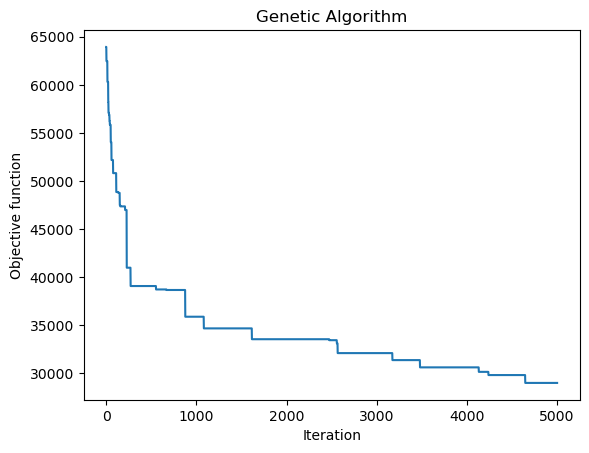

 The best solution found:                                                                           
 [ 1.          1.          1.          0.70919714  2.60924411  1.0512014
 -0.48788559  0.          1.          1.          0.68219098  2.03647398
  1.7518574  -0.25533544  0.          1.          1.          0.56297043
  1.56836326  1.87359637  0.09236733  0.          1.          1.
  0.73240828  2.1054631   1.63774973  0.06774896  0.          1.
  1.          0.80809678  1.24432614  1.81815459 -0.37066345  0.
  1.          1.          0.01817248  1.66376031  3.08474321 -0.40359089
  0.          1.          1.          0.29069357  2.2983107   2.69263517
  0.29515264  0.          1.          1.          0.77156261  1.56702399
  2.65347459  0.1713656   0.          1.          1.          0.92936515
  2.86611793  2.33988629  0.40637625  0.          1.          1.
  0.22086346  1.85144129  3.12650415 -0.39864205  0.          1.
  1.          0.46510406  0.8433791   3.47714996 -0.47762806  0

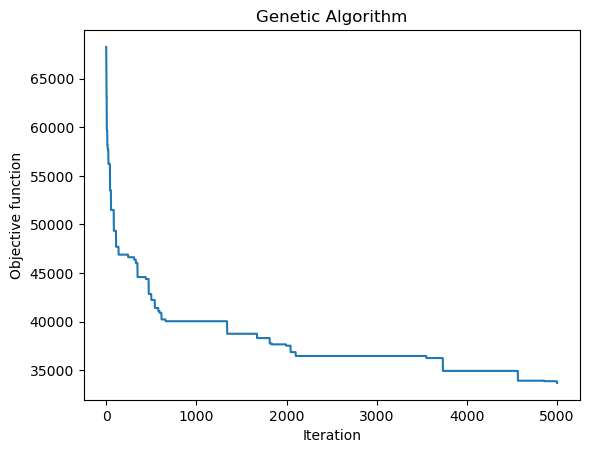

 The best solution found:                                                                           
 [ 0.          1.          1.          0.35836805  2.45176296  1.77324004
 -0.3026301   1.          1.          1.          0.08454863  2.24297155
  1.26579737 -0.04499297  1.          1.          1.          0.59870031
  1.70339285  2.447137    0.21420567  1.          1.          1.
  1.05620556  1.00845847  1.85237305 -0.39956028  1.          1.
  1.          1.39959275  1.45857883  3.49719422 -0.36462949  1.
  1.          1.          0.41236822  1.46630697  2.33681696  0.15744367
  1.          1.          1.          0.3526921   1.13994533  3.5579192
 -0.28257672  0.          1.          1.          1.12508781  1.44869573
  1.09437405 -0.06838956  1.          1.          1.          1.54926194
  2.94172464  0.19761927 -0.31152338  1.          1.          0.
  1.31254558  2.93928499  0.35909284  0.25575234  1.          1.
  0.          1.25043252  2.27562037  2.53134442 -0.06443624  1

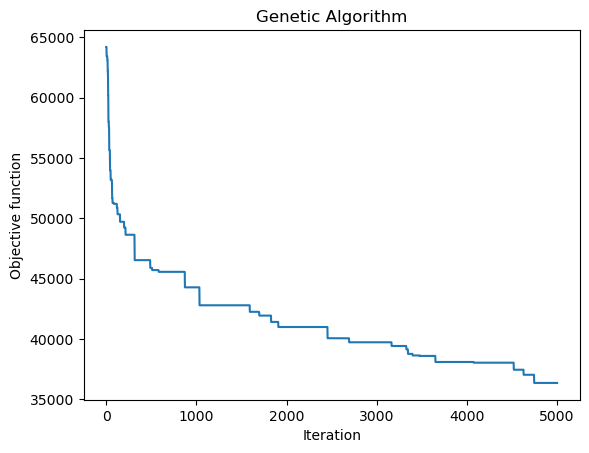

 The best solution found:                                                                           
 [ 0.          1.          1.          0.86331599  2.00951246  2.20021407
 -0.29105001  1.          1.          1.          1.30396729  0.83888547
  1.35036337  0.17105635  1.          0.          1.          1.62802074
  2.26783514  2.51156331 -0.36255539  1.          0.          1.
  1.3062144   0.07913063  2.82428945 -0.24765706  1.          0.
  1.          1.80790863  0.24123471  3.71918987  0.16384062  1.
  1.          1.          1.43538488  1.2042514   3.3369072  -0.44054353
  1.          1.          1.          0.61163381  1.86000955  1.93222135
  0.11162796  1.          1.          1.          0.6761485   1.46146798
  2.96800331 -0.07023833  1.          1.          1.          1.32513654
  2.07061719  1.75983037 -0.1195477   1.          1.          1.
  1.06022371  1.15727688  0.95075791  0.37858183  1.          1.
  1.          0.18260381  1.59767358  0.97076482 -0.05126494  

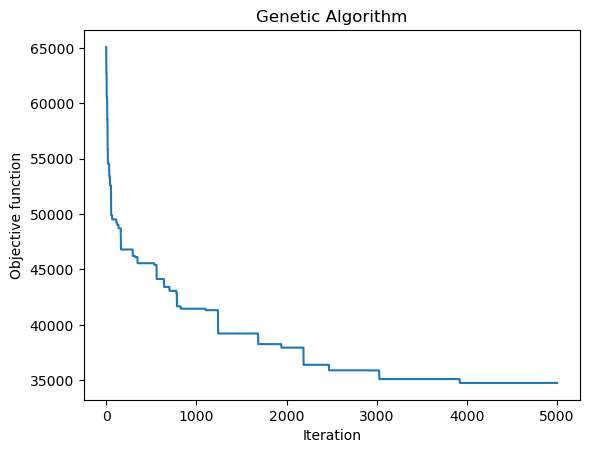

 The best solution found:                                                                           
 [ 1.00000000e+00  1.00000000e+00  1.00000000e+00  7.58707054e-01
  2.42629102e+00  8.92646749e-01 -2.16464783e-01  0.00000000e+00
  1.00000000e+00  1.00000000e+00  6.92684866e-01  2.40998923e+00
  1.71325752e+00  6.25829734e-02  0.00000000e+00  1.00000000e+00
  1.00000000e+00  1.40132154e-01  5.30972842e-01  3.16599060e+00
  9.96231231e-03  0.00000000e+00  1.00000000e+00  1.00000000e+00
  5.79022206e-01  9.18870215e-01  2.53447239e+00  4.53160925e-02
  0.00000000e+00  1.00000000e+00  1.00000000e+00  4.88179709e-01
  1.77650777e+00  3.16256762e+00 -3.40835408e-01  0.00000000e+00
  1.00000000e+00  1.00000000e+00  9.29713452e-01  1.66012850e+00
  3.36257720e+00 -1.15227364e-01  0.00000000e+00  1.00000000e+00
  1.00000000e+00  3.11248927e-03  2.70261973e+00  3.77310796e+00
 -4.87272506e-01  0.00000000e+00  0.00000000e+00  1.00000000e+00
  1.67451355e+00  5.21120993e-02  3.69643639e+00  3.5

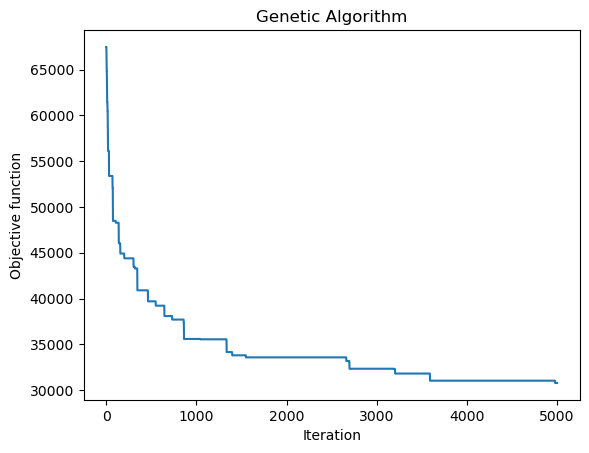

 The best solution found:                                                                           
 [ 1.00000000e+00  1.00000000e+00  1.00000000e+00  1.51610897e+00
  2.20796328e+00  1.81706412e+00 -1.02713362e-01  1.00000000e+00
  1.00000000e+00  1.00000000e+00  5.86447212e-01  2.09452514e+00
  1.27600915e+00  3.99892026e-02  1.00000000e+00  1.00000000e+00
  1.00000000e+00  6.39050143e-01  2.54108880e+00  3.11029704e-01
 -2.65279734e-02  1.00000000e+00  1.00000000e+00  1.00000000e+00
  9.00137829e-02  1.48041139e+00  2.85477056e+00 -8.32356812e-02
  0.00000000e+00  1.00000000e+00  1.00000000e+00  9.34586035e-01
  4.03920740e-01  3.29089505e+00 -2.90504109e-01  0.00000000e+00
  1.00000000e+00  1.00000000e+00  1.24327965e+00  1.43466909e+00
  3.04749197e+00  1.09076519e-01  0.00000000e+00  1.00000000e+00
  1.00000000e+00  1.48933038e+00  2.46214007e+00  2.20170157e+00
  1.89526333e-01  0.00000000e+00  1.00000000e+00  1.00000000e+00
  8.67090152e-01  1.45190505e+00  2.60449612e+00 -3.5

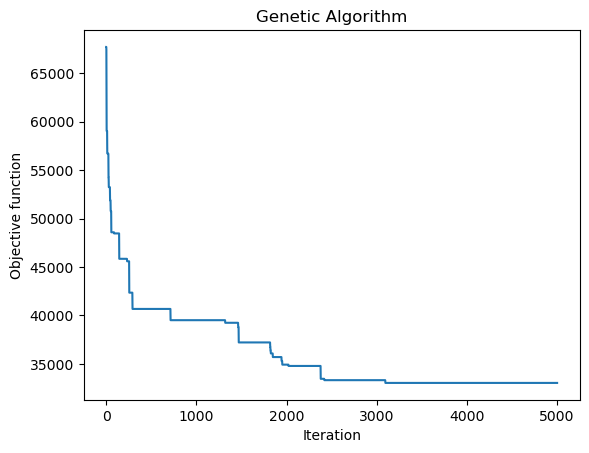

Total time taken was: 1.6429763260814878 hours


In [5]:
# Variable boundaries: [X1, X2, X3, P1, P2, P3, P_energy] * 24
varbound = np.array([[0, 1], [0, 1], [0, 1], [0, 2], [0, 3], [0, 4], [-0.5, 0.5]] * 24)

# Variable type
var_type = np.array([['int'], ['int'], ['int'], ['real'], ['real'], ['real'], ['real']] * 24)

algorithm_param = {'max_num_iteration': 5000,\
                   'population_size':100,\
                   'mutation_probability':0.1,\
                   'elit_ratio': 0.01,\
                   'crossover_probability': 0.5,\
                   'parents_portion': 0.3,\
                   'crossover_type':'uniform',\
                   'max_iteration_without_improv':None}

# List to store results for 50 iterations
all_solutions = []
all_objective_values = []

# Start time
test_start_time = time()

for i in range(20):
    # Create a new Genetic Algorithm model for each run
    model = ga(function=f, dimension=168, variable_type_mixed=var_type, variable_boundaries=varbound, algorithm_parameters=algorithm_param)
        
    # Run the Genetic Algorithm
    model.run()

    # Store the best solution (variables and objective value)
    solution = model.output_dict['variable']
    objective_value = model.output_dict['function']
        
    all_solutions.append(solution)
    all_objective_values.append(objective_value)

# End time
test_end_time = time()

# Calculate the elapsed time
elapsed_time = test_end_time - test_start_time

print(f"Total time taken was: {elapsed_time/3600} hours")

In [6]:
mean_solutions = np.mean(all_solutions, axis=0)
mean_objective_values = np.mean(all_objective_values, axis=0)

# Calculate Ebess with initial conditions
Estart = 0.3  # MWh
Ebess = Estart
B_eff_chg = 0.9
B_eff_dischg = 0.9

previous_status = [1, 0, 0]  # Track previous statuses for startup costs
off_time = [0, 0, 0]  # Track the duration each generator has been off

# Operational cost calculation
total_costs = []

for t in range(24):
    # Mean values of the variables for each time period
    X1 = mean_solutions[t * 7 + 0]
    X2 = mean_solutions[t * 7 + 1]
    X3 = mean_solutions[t * 7 + 2]
    P1 = mean_solutions[t * 7 + 3]
    P2 = mean_solutions[t * 7 + 4]
    P3 = mean_solutions[t * 7 + 5]
    P_energy = mean_solutions[t * 7 + 6]

    # Force power output to zero if the generator is off
    P1 = 0 if X1 < 0.5 else np.clip(P1, P_min[0], P_max[0])
    P2 = 0 if X2 < 0.5 else np.clip(P2, P_min[1], P_max[1])
    P3 = 0 if X3 < 0.5 else np.clip(P3, P_min[2], P_max[2])

    # Power balance and grid power calculation
    total_generation = P1 + P2 + P3 + P_energy + solar_power[t]

    if total_generation < load[t]:
        P_net = load[t] - total_generation
        P_grid = min(P_net, PG_max)
    else:
        P_grid = 0

    # Set bounds for P_charge and P_discharge based on P_energy
    if P_energy < 0:  # Charging mode
        P_charge = -P_energy
        P_discharge = 0
    elif P_energy > 0:  # Discharging mode
        P_discharge = P_energy
        P_charge = 0
    else:
        P_charge = 0
        P_discharge = 0

    # Calculate battery energy
    Ebess = Ebess + (P_charge * B_eff_chg) - (P_discharge / B_eff_dischg)

    # Calculate operational cost
    generation_cost = (a[0] * P1**2 + b[0] * P1 + c[0]) * X1 + \
                      (a[1] * P2**2 + b[1] * P2 + c[1]) * X2 + \
                      (a[2] * P3**2 + b[2] * P3 + c[2]) * X3
    cost_solar = solar_power[t] * PV_costs
    cost_grid = grid_cost[t] * P_grid 
    Ebess_degrad_costs = (Ebess_coef * abs(P_energy)) + (Ebess_coef * Ebess)

    # Calculate startup costs based on generator statuses, previous statuses, and minimum down time
    startup_cost = 0
    # Generator 1
    if X1 >= 0.5 and (previous_status[0] < 0.5):  # If generator 1 was off previously
        if off_time[0] >= min_down_time[0]:  # Cold start if off time >= min down time
            startup_cost += cold_start_cost[0]
        else:  # Hot start if off time < min down time
            startup_cost += hot_start_cost[0]
    if X1 < 0.5:
        off_time[0] += 1  # Increment off time if the generator is off
    else:
        off_time[0] = 0  # Reset off time if the generator is on

    # Generator 2
    if X2 >= 0.5 and (previous_status[1] < 0.5):  # If generator 2 was off previously
        if off_time[1] >= min_down_time[1]:  # Cold start if off time >= min down time
            startup_cost += cold_start_cost[1]
        else:  # Hot start if off time < min down time
            startup_cost += hot_start_cost[1]
    if X2 < 0.5:
        off_time[1] += 1  # Increment off time if the generator is off
    else:
        off_time[1] = 0  # Reset off time if the generator is on

    # Generator 3
    if X3 >= 0.5 and (previous_status[2] < 0.5):  # If generator 3 was off previously
        if off_time[2] >= min_down_time[2]:  # Cold start if off time >= min down time
            startup_cost += cold_start_cost[2]
        else:  # Hot start if off time < min down time
            startup_cost += hot_start_cost[2]
    if X3 < 0.5:
        off_time[2] += 1  # Increment off time if the generator is off
    else:
        off_time[2] = 0  # Reset off time if the generator is on

    # Update previous status
    previous_status = [X1, X2, X3]

    # Calculate total operational cost
    total_operational_cost = generation_cost + cost_solar + cost_grid + Ebess_degrad_costs + startup_cost
    total_costs.append(total_operational_cost)

    # Output the average results for each time period
    print(f"Average at hour {t + 1}:")
    X1_rounded = 0 if X1 < 0.5 else math.ceil(X1)
    X2_rounded = 0 if X2 < 0.5 else math.ceil(X2)
    X3_rounded = 0 if X3 < 0.5 else math.ceil(X3)
    print(f"  Generator 1: Mean Status={X1_rounded}, Mean Power={P1:.2f} kW")
    print(f"  Generator 2: Mean Status={X2_rounded}, Mean Power={P2:.2f} kW")
    print(f"  Generator 3: Mean Status={X3_rounded}, Mean Power={P3:.2f} kW")
    print(f"  Mean Grid Power: {P_grid:.2f} kW")
    print(f"  Mean Battery Power: {P_energy:.2f} kW, (Ebess = {Ebess:.2f} kWh)")
    print(f"  Mean Total Operational Cost at hour {t + 1}: {total_operational_cost:.2f} AUD")
    print()

# After the loop, you can also print or analyze the total costs over all hours
print(f"Mean Total Operational Costs for all hours: {sum(total_costs)} AUD")

Average at hour 1:
  Generator 1: Mean Status=1, Mean Power=0.98 kW
  Generator 2: Mean Status=1, Mean Power=1.74 kW
  Generator 3: Mean Status=1, Mean Power=1.75 kW
  Mean Grid Power: 0.00 kW
  Mean Battery Power: -0.23 kW, (Ebess = 0.50 kWh)
  Mean Total Operational Cost at hour 1: 537.50 AUD

Average at hour 2:
  Generator 1: Mean Status=1, Mean Power=0.80 kW
  Generator 2: Mean Status=1, Mean Power=1.62 kW
  Generator 3: Mean Status=1, Mean Power=1.78 kW
  Mean Grid Power: 0.00 kW
  Mean Battery Power: -0.21 kW, (Ebess = 0.69 kWh)
  Mean Total Operational Cost at hour 2: 455.09 AUD

Average at hour 3:
  Generator 1: Mean Status=1, Mean Power=0.80 kW
  Generator 2: Mean Status=1, Mean Power=1.39 kW
  Generator 3: Mean Status=1, Mean Power=2.01 kW
  Mean Grid Power: 0.00 kW
  Mean Battery Power: -0.03 kW, (Ebess = 0.72 kWh)
  Mean Total Operational Cost at hour 3: 449.83 AUD

Average at hour 4:
  Generator 1: Mean Status=1, Mean Power=0.84 kW
  Generator 2: Mean Status=1, Mean Power=

In [9]:
# Constants for constraint limits
ramp_up = [1, 1.2, 1.5]     # Ramp-up limits for generators
ramp_down = [1, 1.2, 1.5]   # Ramp-down limits for generators
min_up_time = [3, 3, 3]     # Minimum up time for generators
min_down_time = [3, 3, 3]   # Minimum down time for generators
Epwr_min, Epwr_max = -0.5, 0.5  # Battery power constraints (MW)
Ebess_min, Ebess_max = 0.3, 1.5  # Battery energy constraints (MWh)

previous_status = [1, 0, 0]  # Track previous statuses for startup costs
off_time = [0, 0, 0]         # Track the duration each generator has been off
on_time = [0, 0, 0]          # Track the duration each generator has been on
previous_power = [1.5, 0, 0]  # Previous generator power

# Initial battery energy
Ebess = Estart

for t in range(24):
    violations = []

    # Mean values of the variables for each time period
    X1 = mean_solutions[t * 7 + 0]
    X2 = mean_solutions[t * 7 + 1]
    X3 = mean_solutions[t * 7 + 2]
    P1 = mean_solutions[t * 7 + 3]
    P2 = mean_solutions[t * 7 + 4]
    P3 = mean_solutions[t * 7 + 5]
    P_energy = mean_solutions[t * 7 + 6]

    # Force power output to zero if the generator is off
    P1 = 0 if X1 < 0.5 else np.clip(P1, P_min[0], P_max[0])
    P2 = 0 if X2 < 0.5 else np.clip(P2, P_min[1], P_max[1])
    P3 = 0 if X3 < 0.5 else np.clip(P3, P_min[2], P_max[2])

    # Check ramp rate violations
    if X1 >= 0.5 and abs(P1 - previous_power[0]) > ramp_up[0]:
        violations.append(f"Generator 1 ramp-up limit exceeded at hour {t+1}")
    if X1 >= 0.5 and abs(previous_power[0] - P1) > ramp_down[0]:
        violations.append(f"Generator 1 ramp-down limit exceeded at hour {t+1}")
    if X2 >= 0.5 and abs(P2 - previous_power[1]) > ramp_up[1]:
        violations.append(f"Generator 2 ramp-up limit exceeded at hour {t+1}")
    if X2 >= 0.5 and abs(previous_power[1] - P2) > ramp_down[1]:
        violations.append(f"Generator 2 ramp-down limit exceeded at hour {t+1}")
    if X3 >= 0.5 and abs(P3 - previous_power[2]) > ramp_up[2]:
        violations.append(f"Generator 3 ramp-up limit exceeded at hour {t+1}")
    if X3 >= 0.5 and abs(previous_power[2] - P3) > ramp_down[2]:
        violations.append(f"Generator 3 ramp-down limit exceeded at hour {t+1}")

    # Update previous power levels for ramp checking
    previous_power = [P1, P2, P3]

    # Check minimum up/down time violations
    for i, (X, prev_status, on, off) in enumerate(zip([X1, X2, X3], previous_status, on_time, off_time)):
        if X >= 0.5:  # Generator is on
            on_time[i] += 1
            if prev_status < 0.5 and on_time[i] < min_up_time[i]:  # If turned on before minimum up time
                violations.append(f"Generator {i+1} minimum up time violated at hour {t+1}")
            off_time[i] = 0
        else:  # Generator is off
            off_time[i] += 1
            if prev_status >= 0.5 and off_time[i] < min_down_time[i]:  # If turned off before minimum down time
                violations.append(f"Generator {i+1} minimum down time violated at hour {t+1}")
            on_time[i] = 0

    # Update previous status
    previous_status = [X1, X2, X3]

    # Check battery power and energy constraints
    if P_energy < Epwr_min or P_energy > Epwr_max:
        violations.append(f"Battery power limit exceeded at hour {t+1}")
    if Ebess < Ebess_min or Ebess > Ebess_max:
        violations.append(f"Battery energy limit exceeded at hour {t+1}")

    # Calculate new battery energy
    if P_energy < 0:  # Charging
        P_charge = -P_energy
        P_discharge = 0
    else:  # Discharging
        P_charge = 0
        P_discharge = P_energy

    Ebess = Ebess + (P_charge * B_eff_chg) - (P_discharge / B_eff_dischg)

    # Output constraint violations for the current hour
    if violations:
        print(f"Constraint Violations at hour {t + 1}:")
        for violation in violations:
            print(f"  {violation}")
    else:
        print(f"No constraint violations at hour {t + 1}.")

Constraint Violations at hour 1:
  Generator 2 ramp-up limit exceeded at hour 1
  Generator 2 ramp-down limit exceeded at hour 1
  Generator 3 ramp-up limit exceeded at hour 1
  Generator 3 ramp-down limit exceeded at hour 1
  Generator 2 minimum up time violated at hour 1
  Generator 3 minimum up time violated at hour 1
No constraint violations at hour 2.
No constraint violations at hour 3.
No constraint violations at hour 4.
No constraint violations at hour 5.
No constraint violations at hour 6.
No constraint violations at hour 7.
No constraint violations at hour 8.
No constraint violations at hour 9.
No constraint violations at hour 10.
No constraint violations at hour 11.
No constraint violations at hour 12.
No constraint violations at hour 13.
No constraint violations at hour 14.
No constraint violations at hour 15.
No constraint violations at hour 16.
No constraint violations at hour 17.
No constraint violations at hour 18.
No constraint violations at hour 19.
Constraint Violatio

<!-- algorithm_param = {'max_num_iteration': 3000,\
                   'population_size':100,\
                   'mutation_probability':0.1,\
                   'elit_ratio': 0.01,\
                   'crossover_probability': 0.5,\
                   'parents_portion': 0.3,\
                   'crossover_type':'uniform',\
                   'max_iteration_without_improv':None}

model=ga(function=f,\
            dimension=3,\
            variable_type='real',\
            variable_boundaries=varbound,\
            algorithm_parameters=algorithm_param) -->